In [1]:
import pandas as pd
import numpy as np
import glob



day ahead prices (PUN, NORD) (01/2023 - 06/2026)

In [ ]:
# hourly untill September 2025 included

mesi = glob.glob("C:/Users/mapol/OneDrive/Desktop/Python/tesi/DA/orario/*")
frames = []
for i in mesi:
    giorni = glob.glob(f"{i}/*MGPPrezzi.xml") #filtro sul nome perché ci sono anche altri file xml
    for j in giorni:
        mgp = pd.read_xml(j)
        mgp = mgp[["Data","Ora", "PUN", "NORD"]]
        mgp = mgp.dropna()
        frames.append(mgp)
DA_orario = pd.concat(frames)
DA_orario["Data"] = pd.to_datetime(DA_orario["Data"].astype("int64").astype(str), format="%Y%m%d") 
DA_orario = DA_orario.reset_index(drop = True)
DA_orario = DA_orario.loc[DA_orario.index.repeat(4)].reset_index(drop = True)
DA_orario

# mgp = pd.read_xml("C:/Users/mapol/OneDrive/Desktop/Python/tesi/DA/MGP_Prezzi2023010120230131/20230101MGPPrezzi.xml")
# mgp = mgp[["Ora", "PUN", "NORD"]]
# mgp = mgp.dropna()
# mgp

# quarter hourly 

file = glob.glob("C:/Users/mapol/OneDrive/Desktop/Python/tesi/DA/quartorario/*")
frames = []
for i in file:
    giorni = glob.glob(f"{i}/*MGPPrezzi15.xml") 
    for j in giorni:
        ciao = pd.read_xml(j)
        ciao = ciao[["Data", "Periodo", "PUN", "NORD"]]
        ciao = ciao.dropna()
        frames.append(ciao)
quartorario = pd.concat(frames)
quartorario["Data"] = pd.to_datetime(quartorario["Data"].astype("int64").astype(str), format="%Y%m%d") # SEGNA
quartorario["Ora"] = quartorario["Periodo"]
quartorario = quartorario.drop(columns = "Periodo")
quartorario = quartorario.reset_index(drop = True)
quartorario

# ciao = pd.read_xml("C:/Users/mapol/OneDrive/Desktop/Python/tesi/DA/quartorario/MGP_Prezzi2025100120251031/20251001MGPPrezzi15.xml")
# ciao = ciao[["Data", "Periodo", "PUN", "NORD"]]
# ciao = ciao.dropna()
# ciao["Data"] = pd.to_datetime(ciao["Data"].astype("int64").astype(str), format="%Y%m%d") # SEGNA
# ciao["Ora"] = ciao["Periodo"]
# ciao = ciao.drop(columns = "Periodo")
# ciao

DA = pd.concat([DA_orario, quartorario])
DA = DA.reset_index(drop = True)

DA["PUN"] = DA["PUN"].str.replace(",", ".")
DA["NORD"] = DA["NORD"].str.replace(",", ".")
DA["PUN"] = pd.to_numeric(DA["PUN"])
DA["NORD"] = pd.to_numeric(DA["NORD"])



actual generation wind and solar (01/2023 - 06/2026)

In [ ]:
# hourly

file = glob.glob("C:/Users/mapol/OneDrive/Desktop/Python/tesi/GENERATION/ACTUAL ALL/orario/*")
frames = []
for i in file:
    solareolico = pd.read_excel(i, header = (5))
    ws = solareolico[["MTU", "Solar (MW)", "Wind Onshore (MW)", "Fossil Gas (MW)", "Hydro Water Reservoir (MW)", "Hydro Pumped Storage (MW)"]]
    ws ["MTU"] = pd.to_datetime(ws["MTU"].str.split(" - ").str[0].str.split("(").str[0].str.strip(), format = "%d/%m/%Y %H:%M:%S")
    # ws["Solar (MW)"] = pd.to_numeric(ws["Solar (MW)"])
    frames.append(ws)
windsolar = pd.concat(frames)
windsolar = windsolar.replace("-", np.nan)
windsolar = windsolar.dropna()
windsolar ["Solar (MW)"] = pd.to_numeric(windsolar["Solar (MW)"])
windsolar ["Wind Onshore (MW)"] = pd.to_numeric(windsolar["Wind Onshore (MW)"])
# windsolar = windsolar.loc[windsolar.index.repeat(4)]
windsolar = windsolar.iloc[np.arange(len(windsolar)).repeat(4)] #SEGNA !!!
windsolar["MTU"] = windsolar["MTU"] + pd.to_timedelta([0, 15, 30, 45] * (len(windsolar["MTU"]) // 4), unit = "min")
windsolar.index = windsolar["MTU"]
windsolar = windsolar.drop(columns="MTU")
windsolar

# quarter hourly

solareolico = pd.DataFrame()
ws = pd.DataFrame()
file = glob.glob("C:/Users/mapol/OneDrive/Desktop/Python/tesi/GENERATION/ACTUAL ALL/quartorario/*")
frames = []
for i in file:
    solareolico = pd.read_excel(i, header = (5))
    ws = solareolico[["MTU", "Solar (MW)", "Wind Onshore (MW)", "Fossil Gas (MW)", "Hydro Water Reservoir (MW)", "Hydro Pumped Storage (MW)"]]
    ws ["MTU"] = pd.to_datetime(ws["MTU"].str.split(" - ").str[0].str.split("(").str[0].str.strip(), format = "%d/%m/%Y %H:%M:%S")
    # ws["Solar (MW)"] = pd.to_numeric(ws["Solar (MW)"])
    frames.append(ws)
windsolar_quartorario = pd.concat(frames)
windsolar_quartorario = windsolar_quartorario.replace("-", np.nan)
windsolar_quartorario = windsolar_quartorario.dropna()
windsolar_quartorario ["Solar (MW)"] = pd.to_numeric(windsolar_quartorario["Solar (MW)"])
windsolar_quartorario ["Wind Onshore (MW)"] = pd.to_numeric(windsolar_quartorario["Wind Onshore (MW)"])
windsolar_quartorario.index = windsolar_quartorario["MTU"]
# windsolar = windsolar.loc[windsolar.index.repeat(4)]
windsolar_quartorario = windsolar_quartorario.drop(columns="MTU")
windsolar_quartorario

# # solareolico = pd.read_excel("C:/Users/mapol/OneDrive/Desktop/Python/tesi/GENERATION/ACTUAL ALL/AGGREGATED_GENERATION_PER_TYPE_GENERATION_202212312300-202312312300.xlsx", header = (5))
# # ws = solareolico[["MTU", "Solar (MW)", "Wind Onshore (MW)"]]
# # ws ["MTU"] = pd.to_datetime(ws["MTU"].str.split(" - ").str[0].str.split("(").str[0].str.strip(), format = "%d/%m/%Y %H:%M:%S")
# # ws["Solar (MW)"] = pd.to_numeric(ws["Solar (MW)"])
# # # ws.head(24)


solarwind_actual = pd.concat([windsolar, windsolar_quartorario])
solarwind_actual = solarwind_actual.replace(" ", np.nan)
solarwind_actual["Hydro Pumped Storage (MW)"] = pd.to_numeric(solarwind_actual["Hydro Pumped Storage (MW)"])
solarwind_actual

C:\Users\mapol\AppData\Local\Temp\ipykernel_9524\705587939.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ws ["MTU"] = pd.to_datetime(ws["MTU"].str.split(" - ").str[0].str.split("(").str[0].str.strip(), format = "%d/%m/%Y %H:%M:%S")
C:\Users\mapol\AppData\Local\Temp\ipykernel_9524\705587939.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ws ["MTU"] = pd.to_datetime(ws["MTU"].str.split(" - ").str[0].str.split("(").str[0].str.strip(), format = "%d/%m/%Y %H:%M:%S")
C:\Users\mapol\AppData\Local\Temp\ip

,Solar (MW),Wind Onshore (MW),Fossil Gas (MW),Hydro Water Reservoir (MW),Hydro Pumped Storage (MW)
MTU,,,,,
2023-01-01 00:00:00,0.0,31.0,5547.0,198.0,NaN
2023-01-01 00:15:00,0.0,31.0,5547.0,198.0,NaN
2023-01-01 00:30:00,0.0,31.0,5547.0,198.0,NaN
2023-01-01 00:45:00,0.0,31.0,5547.0,198.0,NaN
2023-01-01 01:00:00,0.0,27.0,5212.0,193.0,NaN
...,...,...,...,...,...
2026-07-02 15:15:00,6977.0,45.0,5931.00,259.00,NaN
2026-07-02 15:30:00,6801.0,63.0,6088.00,225.00,NaN
2026-07-02 15:45:00,6595.0,68.0,6185.00,255.00,NaN


In [4]:

solarwind_actual["Fossil Gas (MW)"] = pd.to_numeric(solarwind_actual["Fossil Gas (MW)"])
solarwind_actual["Hydro Water Reservoir (MW)"] = pd.to_numeric(solarwind_actual["Hydro Water Reservoir (MW)"])
solarwind_actual["Hydro Pumped Storage (MW)"] = solarwind_actual["Hydro Pumped Storage (MW)"].replace(np.nan, "0")
solarwind_actual["Hydro Pumped Storage (MW)"] = pd.to_numeric(solarwind_actual["Hydro Pumped Storage (MW)"])
solarwind_actual["is pumping"] = solarwind_actual["Hydro Pumped Storage (MW)"] == 0
solarwind_actual["Hydro Pumped Storage (MW)"]

MTU
2023-01-01 00:00:00      0.0
2023-01-01 00:15:00      0.0
2023-01-01 00:30:00      0.0
2023-01-01 00:45:00      0.0
2023-01-01 01:00:00      0.0
                       ...  
2026-07-02 15:15:00      0.0
2026-07-02 15:30:00      0.0
2026-07-02 15:45:00      0.0
2026-07-02 16:00:00     83.0
2026-07-02 16:15:00    138.0
Name: Hydro Pumped Storage (MW), Length: 122750, dtype: float64

aggregated generation (all sources) forecast and actual (01/2023 - 06/2026)

In [ ]:
# hourly

file = glob.glob("C:/Users/mapol/OneDrive/Desktop/Python/tesi/GENERATION/ACTUAL-FORECAST ALL/orario/*")
frames = []
for i in file:
    tutto = pd.read_excel(i, header = (6))
    all = tutto[["MTU", "Generation Forecast (MW)", "Actual Generation (MW)"]]
    all ["MTU"] = pd.to_datetime(all["MTU"].str.split(" - ").str[0].str.split("(").str[0].str.strip(), format = "%d/%m/%Y %H:%M:%S")
    all = all.replace("-", np.nan)
    all = all.dropna()
    all["Generation Forecast (MW)"] = pd.to_numeric(all["Generation Forecast (MW)"])
    all["Actual Generation (MW)"] = pd.to_numeric(all["Actual Generation (MW)"])
    # all.index = all["MTU"]
    # all = all.drop(columns= "MTU")
    frames.append(all)
agg_gen = pd.concat(frames)
# agg_gen = agg_gen.loc[agg_gen.index.repeat(4)]
agg_gen = agg_gen.iloc[np.arange(len(agg_gen)).repeat(4)] 
agg_gen["MTU"] = agg_gen["MTU"] + pd.to_timedelta([0, 15, 30, 45] * (len(agg_gen["MTU"]) // 4), unit = "min")
agg_gen.index = agg_gen["MTU"]
agg_gen = agg_gen.drop(columns="MTU")
agg_gen

# quarter hourly
 

all = pd.DataFrame()
tutto = pd.DataFrame()
file = glob.glob("C:/Users/mapol/OneDrive/Desktop/Python/tesi/GENERATION/ACTUAL-FORECAST ALL/quartorario/*")
frames = []
for i in file:
    tutto = pd.read_excel(i, header = (6))
    all = tutto[["MTU", "Generation Forecast (MW)", "Actual Generation (MW)"]]
    all ["MTU"] = pd.to_datetime(all["MTU"].str.split(" - ").str[0].str.split("(").str[0].str.strip(), format = "%d/%m/%Y %H:%M:%S")
    all = all.replace("-", np.nan)
    all = all.dropna()
    all["Generation Forecast (MW)"] = pd.to_numeric(all["Generation Forecast (MW)"])
    all["Actual Generation (MW)"] = pd.to_numeric(all["Actual Generation (MW)"])
    all.index = all["MTU"]
    all = all.drop(columns= "MTU")
    frames.append(all)
agg_gen2 = pd.concat(frames)
agg_gen2

total_generation = pd.concat([agg_gen, agg_gen2])
total_generation


# tutto = pd.read_excel("C:/Users/mapol/OneDrive/Desktop/Python/tesi/GENERATION/ACTUAL-FORECAST ALL/GUI_TOTAL_GENERATION_FORECAST_202512312300-202612312300.xlsx", header = (6))
# all = tutto[["MTU", "Generation Forecast (MW)", "Actual Generation (MW)"]]
# all ["MTU"] = pd.to_datetime(all["MTU"].str.split(" - ").str[0].str.split("(").str[0].str.strip(), format = "%d/%m/%Y %H:%M:%S")
# all = all.replace("-", np.nan)
# all = all.dropna()
# all["Generation Forecast (MW)"] = pd.to_numeric(all["Generation Forecast (MW)"])
# all["Actual Generation (MW)"] = pd.to_numeric(all["Actual Generation (MW)"])
# all.index = all["MTU"]
# all = all.drop(columns= "MTU")


C:\Users\mapol\AppData\Local\Temp\ipykernel_9524\38370557.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all ["MTU"] = pd.to_datetime(all["MTU"].str.split(" - ").str[0].str.split("(").str[0].str.strip(), format = "%d/%m/%Y %H:%M:%S")
C:\Users\mapol\AppData\Local\Temp\ipykernel_9524\38370557.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all ["MTU"] = pd.to_datetime(all["MTU"].str.split(" - ").str[0].str.split("(").str[0].str.strip(), format = "%d/%m/%Y %H:%M:%S")
C:\Users\mapol\AppData\Local\Temp\

,Generation Forecast (MW),Actual Generation (MW)
MTU,,
2023-01-01 00:00:00,7464.0,9017.0
2023-01-01 00:15:00,7464.0,9017.0
2023-01-01 00:30:00,7464.0,9017.0
2023-01-01 00:45:00,7464.0,9017.0
2023-01-01 01:00:00,6885.0,8519.0
...,...,...
2026-07-02 15:15:00,19990.0,17111.0
2026-07-02 15:30:00,20330.0,16996.0
2026-07-02 15:45:00,20337.0,16946.0


forecast wind and solar in Day-ahead (01/2023 - 06/2026)

In [ ]:
# SOLAR

# hourly

file = glob.glob("C:/Users/mapol/OneDrive/Desktop/Python/tesi/GENERATION/FORECAST SOLAR/orario/*")
frames = []
for i in file:
    sole = pd.read_excel(i, header = 6)
    solar = sole[["MTU", "Day-ahead (MW)"]]
    solar ["MTU"] = pd.to_datetime(solar["MTU"].str.split(" - ").str[0].str.split("(").str[0].str.strip(), format = "%d/%m/%Y %H:%M:%S")
    solar = solar.replace("-", np.nan)
    solar = solar.dropna()
    solar ["Day-ahead (MW)"] = pd.to_numeric(solar["Day-ahead (MW)"])
    # solar.index = solar["MTU"]
    frames.append(solar)
solar_forecast = pd.concat(frames)
# solar_forecast = solar_forecast.loc[solar_forecast.index.repeat(4)]
solar_forecast = solar_forecast.iloc[np.arange(len(solar_forecast)).repeat(4)] 
solar_forecast["MTU"] = solar_forecast["MTU"] + pd.to_timedelta([0, 15, 30, 45] * (len(solar_forecast["MTU"]) // 4), unit = "min")
solar_forecast.index = solar_forecast["MTU"]
solar_forecast = solar_forecast.drop(columns= "MTU")

# quarter hourly

sole = pd.DataFrame()
solar = pd.DataFrame()
file = glob.glob("C:/Users/mapol/OneDrive/Desktop/Python/tesi/GENERATION/FORECAST SOLAR/quartorario/*")
frames = []
for i in file:
    sole = pd.read_excel(i, header = 6)
    solar = sole[["MTU", "Day-ahead (MW)"]]
    solar ["MTU"] = pd.to_datetime(solar["MTU"].str.split(" - ").str[0].str.split("(").str[0].str.strip(), format = "%d/%m/%Y %H:%M:%S")
    solar = solar.replace("-", np.nan)
    solar = solar.dropna()
    solar ["Day-ahead (MW)"] = pd.to_numeric(solar["Day-ahead (MW)"])
    solar.index = solar["MTU"]
    frames.append(solar)
solar_quartorario = pd.concat(frames)
solar_quartorario = solar_quartorario.drop(columns= "MTU")
solar_quartorario["Day-ahead (MW)"].ne(0).sum() # 26799 su 52508 


solar = pd.concat([solar_forecast, solar_quartorario])
solar

# sole = pd.read_excel("C:/Users/mapol/OneDrive/Desktop/Python/tesi/GENERATION/FORECAST SOLAR/GUI_WIND_SOLAR_GENERATION_FORECAST_SOLAR_202212312300-202312312300.xlsx", header = 6)
# solar = sole[["MTU", "Day-ahead (MW)"]]
# solar ["MTU"] = pd.to_datetime(solar["MTU"].str.split(" - ").str[0].str.split("(").str[0].str.strip(), format = "%d/%m/%Y %H:%M:%S")
# solar = solar.replace("-", np.nan)
# solar = solar.dropna()
# solar ["Day-ahead (MW)"] = pd.to_numeric(solar["Day-ahead (MW)"])
# solar.index = solar["MTU"]


# WIND


# orario 

file = glob.glob("C:/Users/mapol/OneDrive/Desktop/Python/tesi/GENERATION/FORECAST WIND/orario/*")
frames = []
for i in file:
    vento = pd.read_excel(i, header = 6)
    vento = vento[["MTU", "Day-ahead (MW)"]]
    vento ["MTU"] = pd.to_datetime(vento["MTU"].str.split(" - ").str[0].str.split("(").str[0].str.strip(), format = "%d/%m/%Y %H:%M:%S")
    vento = vento.replace("-", np.nan)
    vento = vento.dropna()
    vento ["Day-ahead (MW)"] = pd.to_numeric(vento["Day-ahead (MW)"])
    # vento.index = vento["MTU"]
    frames.append(vento)
wind_forecast = pd.concat(frames)
# wind_forecast = wind_forecast.resample("h").mean()
wind_forecast = wind_forecast.iloc[np.arange(len(wind_forecast)).repeat(4)] 
wind_forecast["MTU"] = wind_forecast["MTU"] + pd.to_timedelta([0, 15, 30, 45] * (len(wind_forecast["MTU"]) // 4), unit = "min")
wind_forecast.index = wind_forecast["MTU"]
wind_forecast = wind_forecast.drop(columns= "MTU")
# wind_forecast = wind_forecast.loc[wind_forecast.index.repeat(4)]
wind_forecast

# quartorario

vento =pd.DataFrame()
file = glob.glob("C:/Users/mapol/OneDrive/Desktop/Python/tesi/GENERATION/FORECAST WIND/quartorario/*")
frames = []
for i in file:
    vento = pd.read_excel(i, header = 6)
    vento = vento[["MTU", "Day-ahead (MW)"]]
    vento ["MTU"] = pd.to_datetime(vento["MTU"].str.split(" - ").str[0].str.split("(").str[0].str.strip(), format = "%d/%m/%Y %H:%M:%S")
    vento = vento.replace("-", np.nan)
    vento = vento.dropna()
    vento ["Day-ahead (MW)"] = pd.to_numeric(vento["Day-ahead (MW)"])
    vento.index = vento["MTU"]
    frames.append(vento)
wind_quartorario = pd.concat(frames)
# wind_forecast = wind_forecast.resample("h").mean()
wind_quartorario = wind_quartorario.drop(columns= "MTU")
# wind_forecast = wind_forecast.loc[wind_forecast.index.repeat(4)]
wind_quartorario

wind = pd.concat([wind_forecast, wind_quartorario])
wind

# vento = pd.read_excel("C:/Users/mapol/OneDrive/Desktop/Python/tesi/GENERATION/FORECAST WIND/GUI_WIND_SOLAR_GENERATION_FORECAST_ONSHORE_202212312300-202312312300.xlsx", header = 6)
# vento = vento[["MTU", "Day-ahead (MW)"]]
# vento ["MTU"] = pd.to_datetime(vento["MTU"].str.split(" - ").str[0].str.split("(").str[0].str.strip(), format = "%d/%m/%Y %H:%M:%S")
# vento = vento.replace("-", np.nan)
# vento = vento.dropna()
# vento ["Day-ahead (MW)"] = pd.to_numeric(vento["Day-ahead (MW)"])
# vento.index = vento["MTU"]

# merge 

solar = solar.rename(columns = {"Day-ahead (MW)": "Solar Forecast (MW)"})
wind = wind.rename(columns = {"Day-ahead (MW)": "Wind Forecast (MW)"})

solarwind_forecast = pd.concat([solar, wind], axis=1) # SEGNA!!!
solarwind_forecast

C:\Users\mapol\AppData\Local\Temp\ipykernel_9524\2884754335.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  solar ["MTU"] = pd.to_datetime(solar["MTU"].str.split(" - ").str[0].str.split("(").str[0].str.strip(), format = "%d/%m/%Y %H:%M:%S")
C:\Users\mapol\AppData\Local\Temp\ipykernel_9524\2884754335.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  solar ["MTU"] = pd.to_datetime(solar["MTU"].str.split(" - ").str[0].str.split("(").str[0].str.strip(), format = "%d/%m/%Y %H:%M:%S")
C:\Users\mapol\AppDa

,Solar Forecast (MW),Wind Forecast (MW)
MTU,,
2023-01-01 00:00:00,0.0,2.0
2023-01-01 00:15:00,0.0,2.0
2023-01-01 00:30:00,0.0,2.0
2023-01-01 00:45:00,0.0,2.0
2023-01-01 01:00:00,0.0,2.0
...,...,...
2026-07-02 22:45:00,0.0,14.0
2026-07-02 23:00:00,0.0,14.0
2026-07-02 23:15:00,0.0,15.0


actual and forecast (in Day-ahead) load (01/2023 - 06/2026)

In [7]:
file = glob.glob("C:/Users/mapol/OneDrive/Desktop/Python/tesi/LOAD/orario/*")
frames = []
for i in file:
    load = pd.read_excel(i, header = 6)
    load = load[["MTU", "Actual Total Load (MW)", "Day-ahead Total Load Forecast (MW)"]]
    load ["MTU"] = pd.to_datetime(load["MTU"].str.split(" - ").str[0].str.split("(").str[0].str.strip(), format = "%d/%m/%Y %H:%M")
    load = load.replace("-", np.nan)
    load = load.dropna()
    load ["Actual Total Load (MW)"] = pd.to_numeric(load["Actual Total Load (MW)"])
    load ["Day-ahead Total Load Forecast (MW)"] = pd.to_numeric(load["Day-ahead Total Load Forecast (MW)"])
    # load.index = load["MTU"]
    frames.append(load)
load_forecast = pd.concat(frames)
# load_forecast = load_forecast.loc[load_forecast.index.repeat(4)]
load_forecast = load_forecast.iloc[np.arange(len(load_forecast)).repeat(4)] 
load_forecast["MTU"] = load_forecast["MTU"] + pd.to_timedelta([0, 15, 30, 45] * (len(load_forecast["MTU"]) // 4), unit = "min")
load_forecast.index = load_forecast["MTU"]
load_forecast = load_forecast.drop(columns= "MTU")
load_forecast

# quartorario
load = pd.DataFrame()
file = glob.glob("C:/Users/mapol/OneDrive/Desktop/Python/tesi/LOAD/quartorario/*")
frames = []
for i in file:
    load = pd.read_excel(i, header = 6)
    load = load[["MTU", "Actual Total Load (MW)", "Day-ahead Total Load Forecast (MW)"]]
    load ["MTU"] = pd.to_datetime(load["MTU"].str.split(" - ").str[0].str.split("(").str[0].str.strip(), format = "%d/%m/%Y %H:%M")
    load = load.replace("-", np.nan)
    load = load.dropna()
    load ["Actual Total Load (MW)"] = pd.to_numeric(load["Actual Total Load (MW)"])
    load ["Day-ahead Total Load Forecast (MW)"] = pd.to_numeric(load["Day-ahead Total Load Forecast (MW)"])
    load.index = load["MTU"]
    frames.append(load)
load_quarto = pd.concat(frames)
# load_forecast = load_forecast.loc[load_forecast.index.repeat(4)]
load_quarto = load_quarto.drop(columns= "MTU")
load_quarto

load = pd.concat([load_forecast, load_quarto])
load


,Actual Total Load (MW),Day-ahead Total Load Forecast (MW)
MTU,,
2023-01-01 00:00:00,10447.0,10082.0
2023-01-01 00:15:00,10447.0,10082.0
2023-01-01 00:30:00,10447.0,10082.0
2023-01-01 00:45:00,10447.0,10082.0
2023-01-01 01:00:00,10018.0,9383.0
...,...,...
2026-07-02 13:00:00,21293.0,21946.0
2026-07-02 13:15:00,21367.0,22334.0
2026-07-02 13:30:00,21677.0,22510.0


MB Price and Volume (TERNA) (01/2023 - 06/2026)

In [ ]:

file = glob.glob("C:/Users/mapol/OneDrive/Desktop/Python/tesi/MB/*")
frames = []
for i in file:
    mb = pd.read_excel(i, header = (1))
    mb = mb[["Data Riferimento", "Macrozona", "Sbil aggregato zonale [MWh]", "Segno aggregato zonale", "Prezzo di sbilanciamento"]]
    mb["MTU"] = pd.to_datetime(mb["Data Riferimento"], format = "%d/%m/%Y %H:%M:%S")
    mb = mb.replace("SUD", np.nan)
    mb = mb.dropna()
    mb.index = mb["MTU"]
    mb = mb.drop(columns = ["Data Riferimento", "MTU"])
    frames.append(mb)
mb_final = pd.concat(frames)
mb_final["Sbil aggregato zonale [MWh]"] = pd.to_numeric(mb_final["Sbil aggregato zonale [MWh]"])
mb_final["Prezzo di sbilanciamento"]  = pd.to_numeric(mb_final["Prezzo di sbilanciamento"])
mb_final = mb_final.drop(columns = ["Segno aggregato zonale"])
mb_final = mb_final.drop(columns = ["Macrozona"])
# mb_final = mb_final.resample("h").mean()
mb_final



,Sbil aggregato zonale [MWh],Prezzo di sbilanciamento
MTU,,
2023-01-01 00:00:00,159.946,151.951
2023-01-01 00:15:00,45.503,195.900
2023-01-01 00:30:00,54.336,195.900
2023-01-01 00:45:00,81.649,195.900
2023-01-01 01:00:00,-26.077,325.871
...,...,...
2026-06-30 22:45:00,-69.578,200.639
2026-06-30 23:00:00,-128.288,165.000
2026-06-30 23:15:00,-92.811,142.031


Merge

In [9]:
mercato = pd.merge(solarwind_actual, total_generation, on = "MTU")
mercato = pd.merge(mercato, solarwind_forecast, on = "MTU")
mercato = pd.merge(mercato, load, on = "MTU")
mercato = pd.merge(mercato, mb_final, on = "MTU")
DA["MTU"] = mb_final.index
DA = DA.drop(columns = ["Ora", "Data"])
mercato = pd.merge(DA, mercato, on = "MTU")
mercato 

,PUN,NORD,MTU,Solar (MW),Wind Onshore (MW),Fossil Gas (MW),Hydro Water Reservoir (MW),Hydro Pumped Storage (MW),is pumping,Generation Forecast (MW),Actual Generation (MW),Solar Forecast (MW),Wind Forecast (MW),Actual Total Load (MW),Day-ahead Total Load Forecast (MW),Sbil aggregato zonale [MWh],Prezzo di sbilanciamento
0,195.90,195.90,2023-01-01 00:00:00,0.0,31.0,5547.0,198.0,0.0,True,7464.0,9017.0,0.0,2.0,10447.0,10082.0,159.946,151.951
1,195.90,195.90,2023-01-01 00:15:00,0.0,31.0,5547.0,198.0,0.0,True,7464.0,9017.0,0.0,2.0,10447.0,10082.0,45.503,195.900
2,195.90,195.90,2023-01-01 00:30:00,0.0,31.0,5547.0,198.0,0.0,True,7464.0,9017.0,0.0,2.0,10447.0,10082.0,54.336,195.900
3,195.90,195.90,2023-01-01 00:45:00,0.0,31.0,5547.0,198.0,0.0,True,7464.0,9017.0,0.0,2.0,10447.0,10082.0,81.649,195.900
4,191.09,191.09,2023-01-01 01:00:00,0.0,27.0,5212.0,193.0,0.0,True,6885.0,8519.0,0.0,2.0,10018.0,9383.0,-26.077,325.871
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121479,159.80,159.80,2026-06-30 22:45:00,0.0,1.0,14830.0,556.0,668.0,False,23122.0,21283.0,0.0,7.0,24167.0,25077.0,-69.578,200.639
121480,165.00,165.00,2026-06-30 23:00:00,0.0,1.0,14811.0,493.0,57.0,False,22195.0,20330.0,0.0,8.0,23746.0,24527.0,-128.288,165.000
121481,140.00,140.00,2026-06-30 23:15:00,0.0,1.0,14549.0,366.0,50.0,False,21582.0,19842.0,0.0,9.0,23320.0,23967.0,-92.811,142.031
121482,135.45,135.45,2026-06-30 23:30:00,0.0,1.0,14309.0,330.0,0.0,True,21422.0,19479.0,0.0,8.0,22618.0,23604.0,-53.321,144.651


In [10]:
m = pd.DataFrame()
m = mercato.set_index("MTU").sort_index()

# prezzo e volume
m["Sbil shiftato"] = m["Sbil aggregato zonale [MWh]"].shift(96)
m["Prezzo shiftato"] = m["Prezzo di sbilanciamento"].shift(96)

# errori laggati
m["delta_load"] = (m["Actual Total Load (MW)"] - m["Day-ahead Total Load Forecast (MW)"]).shift(4)
m["delta_res"] = (m["Wind Onshore (MW)"] + m["Solar (MW)"] - m["Wind Forecast (MW)"] - m["Solar Forecast (MW)"]).shift(4)
m["delta_gen"] = (m["Day-ahead Total Load Forecast (MW)"] - m["Generation Forecast (MW)"]).shift(4)

# net load e rampe — driver primario di fragilità
m["NetLoad_fc"]   = m["Day-ahead Total Load Forecast (MW)"] - m["Solar Forecast (MW)"] - m["Wind Forecast (MW)"]
m["Ramp_15"]      = m["NetLoad_fc"].diff()
m["Ramp_60"]      = m["NetLoad_fc"].diff(4)
m["Ramp_accel"]   = m["Ramp_15"].diff()

# margine programmato
m["Margin_fc"]    = m["Generation Forecast (MW)"] - m["Day-ahead Total Load Forecast (MW)"]

# calendario + break strutturale
m["hour"] = m.index.hour
m["qh"] = m.index.minute // 15
m["day"] = m.index.dayofweek
m["weekend"] = m["day"] > 4

# gas, hydro 
m["Flex_online_lag"] = (m["Fossil Gas (MW)"] + m["Hydro Water Reservoir (MW)"] + m["Hydro Pumped Storage (MW)"]).shift(4)
m["Gas_share_lag"] = (m["Fossil Gas (MW)"] / m["Actual Generation (MW)"]).shift(4)

# spread NORD-PUN come proxy congestioni
m["spread_NORD_PUN"] = m["PUN"] - m["NORD"]

# thin / THICK
m["thin"] = m["Sbil aggregato zonale [MWh]"].abs() <= 50
m["thin shift"] = m["thin"].shift(96) # pubblicati alle 17 del giorno dopo, prendo 24 h

m


,PUN,NORD,Solar (MW),Wind Onshore (MW),Fossil Gas (MW),Hydro Water Reservoir (MW),Hydro Pumped Storage (MW),is pumping,Generation Forecast (MW),Actual Generation (MW),...,Margin_fc,hour,qh,day,weekend,Flex_online_lag,Gas_share_lag,spread_NORD_PUN,thin,thin shift
MTU,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,195.90,195.90,0.0,31.0,5547.0,198.0,0.0,True,7464.0,9017.0,...,-2618.0,0,0,6,True,NaN,NaN,0.0,False,NaN
2023-01-01 00:15:00,195.90,195.90,0.0,31.0,5547.0,198.0,0.0,True,7464.0,9017.0,...,-2618.0,0,1,6,True,NaN,NaN,0.0,True,NaN
2023-01-01 00:30:00,195.90,195.90,0.0,31.0,5547.0,198.0,0.0,True,7464.0,9017.0,...,-2618.0,0,2,6,True,NaN,NaN,0.0,False,NaN
2023-01-01 00:45:00,195.90,195.90,0.0,31.0,5547.0,198.0,0.0,True,7464.0,9017.0,...,-2618.0,0,3,6,True,NaN,NaN,0.0,False,NaN
2023-01-01 01:00:00,191.09,191.09,0.0,27.0,5212.0,193.0,0.0,True,6885.0,8519.0,...,-2498.0,1,0,6,True,5745.0,0.615171,0.0,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-30 22:45:00,159.80,159.80,0.0,1.0,14830.0,556.0,668.0,False,23122.0,21283.0,...,-1955.0,22,3,1,False,16072.0,0.681643,0.0,False,False
2026-06-30 23:00:00,165.00,165.00,0.0,1.0,14811.0,493.0,57.0,False,22195.0,20330.0,...,-2332.0,23,0,1,False,16351.0,0.682210,0.0,False,False
2026-06-30 23:15:00,140.00,140.00,0.0,1.0,14549.0,366.0,50.0,False,21582.0,19842.0,...,-2385.0,23,1,1,False,16259.0,0.689226,0.0,False,False


API call from Terna: Marg up and down as proxy for acceptance

In [19]:
msd6 = pd.read_parquet("C:/Users/mapol/OneDrive/Desktop/Python/tesi/TERNA_API/msd6_wide.parquet")
msd6 = msd6.replace(["Sardinia", "Calabria", "Centre-North", "Centre-South", "Sicily", "South"], np.nan)
msd6 = msd6.dropna(subset=["zone"]).reset_index()
# msd6["MTU"] = msd6["ts"]
msd6["ts"] = msd6["ts"].astype(str)
msd6["ts"] = msd6["ts"].str.split("+").str[0]
msd6["MTU"] = pd.to_datetime(msd6["ts"])
msd6 = msd6.drop(columns = "ts")
msd6["data"] = msd6["MTU"].dt.date

# non tutto orario

msd6.iloc[17140] # orario fino a 31/12/2025
msd6.iloc[17501] # quartorario da 1/1/2025
a = msd6[msd6["MTU"] < "2025-01-01"]
b = msd6[msd6["MTU"] > "2024-12-31"]
a = a.loc[a.index.repeat(4)]
a["MTU"] = a["MTU"] + pd.to_timedelta([0, 15, 30, 45] * (len(a) // 4), unit = "min")
msd6 = pd.concat([a,b])

# unisco a m 

msd6 = msd6.set_index("MTU").sort_index()
sel = msd6[["MARG_UP","AVG_UP","spread_up","MARG_DOWN","spread_down"]]

sel["had_acceptance"] = sel["MARG_UP"] !=0

# m = pd.merge(m, sel, on = "MTU")
# mi toglieva 3 mila dati, evitiamo
sel

C:\Users\mapol\AppData\Local\Temp\ipykernel_9524\2513171311.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sel["had_acceptance"] = sel["MARG_UP"] !=0


,MARG_UP,AVG_UP,spread_up,MARG_DOWN,spread_down,had_acceptance
MTU,,,,,,
2023-01-01 00:00:00,312.0,312.0,0.0,124.00,9.54,True
2023-01-01 00:15:00,312.0,312.0,0.0,124.00,9.54,True
2023-01-01 00:30:00,312.0,312.0,0.0,124.00,9.54,True
2023-01-01 00:45:00,312.0,312.0,0.0,124.00,9.54,True
2023-01-01 01:00:00,0.0,0.0,0.0,124.00,7.86,False
...,...,...,...,...,...,...
2026-06-30 22:45:00,0.0,0.0,0.0,100.50,0.00,False
2026-06-30 23:00:00,0.0,0.0,0.0,95.60,2.09,False
2026-06-30 23:15:00,0.0,0.0,0.0,95.60,2.22,False


MODELLING

In [20]:
# LASSO regression
from sklearn.linear_model import LassoCV
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit


punctual volume regression

In [ ]:
# LASSO regression

train = m[m.index < "2026-01-01"]
test  = m[m.index >= "2026-01-01"]

feats = ['Sbil shiftato', 'Prezzo shiftato',
         'delta_load', 'delta_res', 'delta_gen', 'NetLoad_fc',
         'Ramp_60', 'Margin_fc', 'hour', 'qh', 'day', 'weekend',
         'Flex_online_lag', 'Gas_share_lag', 'spread_NORD_PUN',
        ]
target = "Sbil aggregato zonale [MWh]"

tr = train[feats + [target]].dropna()
te = test[feats + [target]].dropna()

X_train, Y_train = tr[feats], tr[target]
X_test,  Y_test  = te[feats], te[target]

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)      # transform, NON fit_transform

model = LassoCV(alphas=np.logspace(-3, 1, 50), cv=TimeSeriesSplit(n_splits=5), max_iter=10000)
model.fit(X_train_s, Y_train)
Y_pred = model.predict(X_test_s)

rmse = root_mean_squared_error(Y_test, Y_pred)
print("alpha:", model.alpha_)
print("RMSE:", rmse, "| /std:", rmse / Y_test.std())
print(pd.Series(model.coef_, index=feats).sort_values(key=abs, ascending=False))



alpha: 1.2648552168552958
RMSE: 119.05617353450536 | /std: 0.9134708773124345
delta_load        -38.456033
Sbil shiftato      35.133053
delta_res          22.938919
NetLoad_fc        -22.742698
weekend            -7.895540
hour                6.229703
spread_NORD_PUN    -4.959018
Gas_share_lag      -3.031844
Margin_fc          -1.502881
Prezzo shiftato     0.000000
delta_gen           0.000000
Ramp_60            -0.000000
qh                  0.000000
day                 0.000000
Flex_online_lag    -0.000000
dtype: float64


it is more useful to try to predict market regime rather than punctual volume

In [ ]:
# LASSO regression

train = m[m.index < "2026-01-01"]
test  = m[m.index >= "2026-01-01"]

feats = ['Sbil shiftato', 'Prezzo shiftato',
         'delta_load', 'delta_res', 'delta_gen', 'NetLoad_fc',
         'Ramp_60', 'Margin_fc', 'hour', 'qh', 'day', 'weekend',
         'Flex_online_lag', 'Gas_share_lag', 'spread_NORD_PUN',
         "thin shift"]
target = "thin"

tr = train[feats + [target]].dropna()
te = test[feats + [target]].dropna()

X_train, Y_train = tr[feats], tr[target]
X_test,  Y_test  = te[feats], te[target]

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)      # transform, NON fit_transform

model = LassoCV(alphas=np.logspace(-3, 1, 50), cv=TimeSeriesSplit(n_splits=5), max_iter=10000)
model.fit(X_train_s, Y_train)
Y_pred = model.predict(X_test_s)

rmse = root_mean_squared_error(Y_test, Y_pred)
print("alpha:", model.alpha_)
print("RMSE:", rmse, "| /std:", rmse / Y_test.std())
print(pd.Series(model.coef_, index=feats).sort_values(key=abs, ascending=False))



alpha: 0.001
RMSE: 0.4851256406785591 | /std: 0.987028362551866
Flex_online_lag   -0.082756
Gas_share_lag      0.061508
Margin_fc          0.048563
NetLoad_fc         0.042313
Ramp_60           -0.038340
thin shift         0.031951
hour              -0.027506
delta_load         0.015587
spread_NORD_PUN    0.009966
delta_res         -0.007701
Sbil shiftato     -0.005377
day                0.003828
qh                -0.003003
weekend           -0.000473
Prezzo shiftato   -0.000208
delta_gen         -0.000000
dtype: float64


In [23]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import balanced_accuracy_score, confusion_matrix

train = m[m.index < "2026-01-01"]
test  = m[m.index >= "2026-01-01"]

feats = ['Sbil shiftato', 'Prezzo shiftato',
         'delta_load', 'delta_res', 'delta_gen', 'NetLoad_fc',
         'Ramp_60', 'Margin_fc', 'hour', 'qh', 'day', 'weekend',
         'Flex_online_lag', 'Gas_share_lag', 'spread_NORD_PUN',
         "thin shift", "PUN"]
target = "thin"

tr = train[feats + [target]].dropna()
te = test[feats + [target]].dropna()

X_train, Y_train = tr[feats], tr[target].astype(int)
X_test,  Y_test  = te[feats], te[target].astype(int)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

clf = LogisticRegressionCV(
    Cs=np.logspace(-3, 2, 30),
    penalty="l1", solver="saga",
    cv=TimeSeriesSplit(n_splits=5),
    scoring="balanced_accuracy",
    class_weight="balanced",
    max_iter=5000, n_jobs=-1
)
clf.fit(X_train_s, Y_train)

Y_pred  = clf.predict(X_test_s)
P_thin  = clf.predict_proba(X_test_s)[:, 1]      # servirà al Layer 2

ba    = balanced_accuracy_score(Y_test, Y_pred)
naive = balanced_accuracy_score(Y_test, np.ones_like(Y_test))   # "sempre THIN"

print("base rate THIN (test):", Y_test.mean().round(3))
print("balanced accuracy modello:", round(ba, 4))
print("balanced accuracy naive  :", round(naive, 4))
print(confusion_matrix(Y_test, Y_pred))
print(pd.Series(clf.coef_[0], index=feats).sort_values(key=abs, ascending=False))

base rate THIN (test): 0.408
balanced accuracy modello: 0.5482
balanced accuracy naive  : 0.5
[[2535 7747]
 [1064 6026]]
Flex_online_lag   -0.513165
NetLoad_fc         0.308725
Gas_share_lag      0.296231
Margin_fc          0.229960
Ramp_60           -0.217628
thin shift         0.141564
hour              -0.120619
delta_load         0.092433
delta_res         -0.050591
spread_NORD_PUN    0.045166
day                0.040746
Sbil shiftato     -0.039518
PUN                0.038835
delta_gen         -0.036326
weekend           -0.026502
qh                -0.018548
Prezzo shiftato   -0.015914
dtype: float64


In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=50,        # regolarizza: foglie grandi, meno overfit sul rumore
    max_features="sqrt",
    class_weight="balanced",
    random_state=42, n_jobs=-1
)
rf.fit(X_train, Y_train)        # niente scaler: gli alberi non ne hanno bisogno

Y_pred_rf = rf.predict(X_test)
P_thin_rf = rf.predict_proba(X_test)[:, 1]

print("BA logistica:", round(ba, 4))
print("BA random forest:", round(balanced_accuracy_score(Y_test, Y_pred_rf), 4))
print("BA naive:", 0.5)
print(confusion_matrix(Y_test, Y_pred_rf))
print(pd.Series(rf.feature_importances_, index=feats).sort_values(ascending=False).head(10))

# 40.8 % base
# precision: 4133/8533 = 51.6%
# guadagno 11 punti sul thin
# lift = 1.26

BA logistica: 0.5482
BA random forest: 0.6093
BA naive: 0.5
[[6149 4133]
 [2690 4400]]
hour               0.137763
Sbil shiftato      0.109497
delta_load         0.085442
delta_res          0.071828
Gas_share_lag      0.067672
Ramp_60            0.067013
Margin_fc          0.066275
delta_gen          0.066188
NetLoad_fc         0.066110
Flex_online_lag    0.063130
dtype: float64


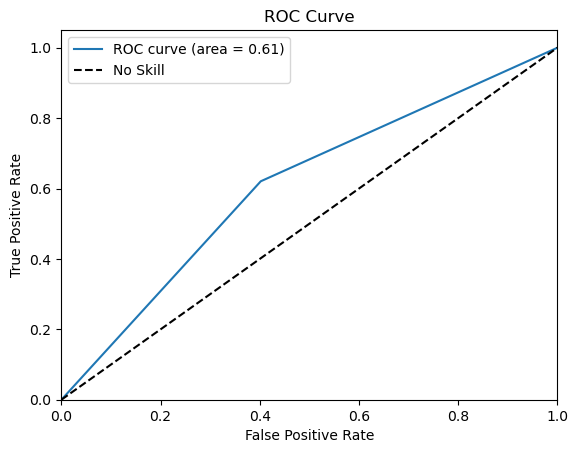

In [25]:
# roc curve
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(Y_test, Y_pred_rf) 
roc_auc = auc(fpr, tpr)

plt.figure()  
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [26]:
# for s in [0, 1, 42, 123, 2024]:
#     rf_s = RandomForestClassifier(n_estimators=300, min_samples_leaf=50,
#                                   max_features="sqrt", class_weight="balanced",
#                                   random_state=s, n_jobs=-1).fit(X_train, Y_train)
#     print(s, round(balanced_accuracy_score(Y_test, rf_s.predict(X_test)), 4))

# # Spread di 0.0027 su cinque seed. In tesi lo scrivi come 0.608 ± 0.001 — la varianza del modello è trascurabile, il numero è quello.

# # 0 0.6069
# # 1 0.6074
# # 42 0.6096
# # 123 0.6085
# # 2024 0.6089


In [27]:
# print((te["Prezzo shiftato"] < 0).sum(), "su", len(te))
# print((tr["Prezzo shiftato"] < 0).sum(), "su", len(tr))

# 8 su 17372
# 526 su 104016

In [ ]:
tagli = m.loc[m.index < "2026-01-01", "Prezzo di sbilanciamento"].quantile([0.33, 0.67])
lo, hi = tagli.iloc[0], tagli.iloc[1]

m["fascia"] = pd.cut(m["Prezzo di sbilanciamento"], bins=[-np.inf, lo, hi, np.inf], labels=["low", "mid", "high"])
m["fascia shift"] = m["fascia"].shift(96).map({"low": 0, "mid": 1, "high": 2})

train = m[m.index < "2026-01-01"]
test  = m[m.index >= "2026-01-01"]

feats2 = ['Sbil shiftato', 'Prezzo shiftato', 'fascia shift', 'thin shift',
          'delta_load', 'delta_res', 'delta_gen', 'NetLoad_fc',
          'Ramp_60', 'Margin_fc', 'hour', 'qh', 'day', 'weekend',
          'Flex_online_lag', 'Gas_share_lag', 'spread_NORD_PUN',
          "PUN"]

tr2 = train[feats2 + ["fascia"]].dropna()
te2 = test[feats2 + ["fascia"]].dropna()

X_tr2, Y_tr2 = tr2[feats2], tr2["fascia"].astype(str)
X_te2, Y_te2 = te2[feats2], te2["fascia"].astype(str)

rf2 = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=50, max_features="sqrt",
    class_weight="balanced", random_state=42, n_jobs=-1
)
rf2.fit(X_tr2, Y_tr2)

pred2  = rf2.predict(X_te2)
proba2 = rf2.predict_proba(X_te2)          # colonne in rf2.classes_

ba2    = balanced_accuracy_score(Y_te2, pred2)
naive2 = balanced_accuracy_score(Y_te2, np.full(len(Y_te2), "mid"))

print("BA random forest :", round(ba2, 4))
print("BA naive (mid)   :", round(naive2, 4), " | teorico 1/3 = 0.333")
print("classi:", rf2.classes_)
print(confusion_matrix(Y_te2, pred2, labels=["low", "mid", "high"]))
print(pd.Series(rf2.feature_importances_, index=feats2)
      .sort_values(ascending=False).head(10))

# lift 1,42 e 1,46 per mid e high, 
# lift 2,45 per low

# ottimizza alpha nei due mercati
# cerca bidding strategie  su scopus 


BA random forest : 0.5623
BA naive (mid)   : 0.3333  | teorico 1/3 = 0.333
classi: ['high' 'low' 'mid']
[[2301  853  647]
 [ 947 4015 2907]
 [1049 1395 3258]]
PUN                0.164902
Flex_online_lag    0.140704
delta_load         0.097832
Gas_share_lag      0.096786
Prezzo shiftato    0.091742
Sbil shiftato      0.061393
NetLoad_fc         0.061246
delta_res          0.051125
fascia shift       0.048586
Ramp_60            0.034690
dtype: float64


old section. acceptance was related only to price. by doing so, I was not able to capture the advantage of introducing one different coefficient per each market regime

Strategy A

In [29]:
# # All or nothing solo a salire basato sul prezzo delle 24 ore prima

# A = m[["Sbil aggregato zonale [MWh]", "Prezzo di sbilanciamento", "PUN"]]
# # m.columns
# # A ["MARG_UP"] = sel["MARG_UP"]
# # A ["MARG_DOWN"] = sel["MARG_DOWN"]
# A = A.join(sel[["MARG_UP", "MARG_DOWN", "had_acceptance"]])
# A["bid"] = A["Prezzo di sbilanciamento"].shift(96)
# A["up"]  = A["Sbil aggregato zonale [MWh]"].shift(96) <0
# # A up = True se sbilanciamento negativo. in tal caso, il sistema è a corto ed è necessario l'intervento degli operatori (che vendano la loro energia)

# P = 10 # taglia BESS = 10 MW
# Q_max = P*0.25 # 10 MW * 15 min = 2,5 MWh

# # Accettazione totalmente misurata sul bid, non sul volume
# A = A.dropna() # perdo il primo giorno, amen: tanto il backtest è fatto sul 2026, non sul 2023        
# A["acc"] = np.where(A["up"], (A["had_acceptance"] == True) & (A["bid"] <= A["MARG_UP"]), (A["had_acceptance"] == True) & (A["bid"] >= A["MARG_DOWN"]))
# A
# A["pnl"] = A["acc"] * Q_max * np.where(A["up"], A["bid"] - A["PUN"], A["PUN"] - A["bid"])
# A_test = A[A.index > "2026-01-01"]
# A_test
# print("PnL strategia A:", A_test["pnl"].sum())
# print("tasso di accettazione percentuale:", 100*A_test["acc"].sum()/len(A_test))

# risultati

# PnL: 162115
# acceptance rate: 8.3%



In [30]:
# # All or nothing solo a salire basato sul prezzo delle 24 ore prima
# # offro se sono sopra il pun, se no no

# A = pd.DataFrame()
# A_test = pd.DataFrame()

# A = m[["Sbil aggregato zonale [MWh]", "Prezzo di sbilanciamento", "PUN"]]
# # m.columns
# # A ["MARG_UP"] = sel["MARG_UP"]
# # A ["MARG_DOWN"] = sel["MARG_DOWN"]
# A = A.join(sel[["MARG_UP", "MARG_DOWN", "had_acceptance"]])
# A["bid"] = A["Prezzo di sbilanciamento"].shift(96)
# A["up"]  = A["Sbil aggregato zonale [MWh]"].shift(96) <0
# A["offer"] = np.where(A["up"], A["bid"] > A["PUN"], A["bid"] < A["PUN"])
# A["thin"] = A["Sbil aggregato zonale [MWh]"].abs() <= 50
# # A up = True se sbilanciamento negativo. in tal caso, il sistema è a corto ed è necessario l'intervento degli operatori (che vendano la loro energia)

# P = 10 # taglia BESS = 10 MW
# Q_max = P*0.25 # 10 MW * 15 min = 2,5 MWh

# # Accettazione totalmente misurata sul bid, non sul volume
# A = A.dropna() # perdo il primo giorno, amen: tanto il backtest è fatto sul 2026, non sul 2023        
# A["acc"] = A["offer"] & np.where(A["up"], (A["had_acceptance"] == True) & (A["bid"] <= A["MARG_UP"]), (A["had_acceptance"] == True) & (A["bid"] >= A["MARG_DOWN"]))
# A
# A["pnl"] = A["acc"] * Q_max * np.where(A["up"], A["bid"] - A["PUN"], A["PUN"] - A["bid"])
# A_test = A[A.index > "2026-01-01"]
# A_test
# print("PnL strategia A:", A_test["pnl"].sum())
# print("tasso di accettazione percentuale:", 100*A_test["acc"].sum()/A_test["offer"].sum())

# risultati

# PnL: 172792
# acceptance rate: 7.5%


thin market has lower acceptance. but still, the alphas were the same

In [ ]:
# g = A_test.groupby("thin")
# desc = pd.DataFrame({
#     "n": g.size(),
#     "std_prezzo_MB": g["Prezzo di sbilanciamento"].std(),
#     "IQR_prezzo_MB": g["Prezzo di sbilanciamento"].quantile(0.75) - g["Prezzo di sbilanciamento"].quantile(0.25),
#     "quota_no_acceptance": 1 - g["had_acceptance"].mean(),
#     "acc_rate_A": g["acc"].sum() / g["offer"].sum(),
# }).rename(index={True: "thin", False: "thick"})
# print(desc.round(3))

# accettazione dimezzata in regime thin
#e allora perche non cambia alpha?
# perche è legato ai prezzi, proviamo a legare ai volumi l'acceptance

si ma gli alpha sono uguali

In [32]:
# Alpha ex post (leakage voluto): bid × alpha, uno per thin e uno per thick

# grid = np.arange(0.5, 2.01, 0.05)
# out = {}
# for reg, mask in [("thin", A_test["thin"]), ("thick", ~A_test["thin"])]:
#     T = A_test[mask]
#     pnl = []
#     for a in grid:
#         b = T["bid"] * a
#         off = np.where(T["up"], b > T["PUN"], b < T["PUN"])
#         acc = off & (T["had_acceptance"] == True) & np.where(T["up"], b <= T["MARG_UP"], b >= T["MARG_DOWN"])
#         pnl.append((acc * Q_max * np.where(T["up"], b - T["PUN"], T["PUN"] - b)).sum())
#     out[reg] = pd.Series(pnl, index=grid.round(2))
#     print(f"{reg}: alpha* = {out[reg].idxmax()}, pnl = {out[reg].max():.0f}")

# print("PnL con alpha ottimi:", round(out["thin"].max() + out["thick"].max()), "| A:", round(A_test["pnl"].sum()))

# alpha era 0.95 per entrambi


introducing Volume constraint in acceptance

In [ ]:
# All or nothing based on the price of the day before
# operator bids only if the imbalance price is below/above the PUN, depending on the sign of the imbalance

A = pd.DataFrame()
A_test = pd.DataFrame()

A = m[["Sbil aggregato zonale [MWh]", "Prezzo di sbilanciamento", "PUN"]]
A = A.join(sel[["MARG_UP", "MARG_DOWN", "had_acceptance"]])
A["bid"] = A["Prezzo di sbilanciamento"].shift(96)
A["up"]  = A["Sbil aggregato zonale [MWh]"].shift(96) <0
A["offer"] = np.where(A["up"], A["bid"] > A["PUN"], A["bid"] < A["PUN"])
A["thin"] = A["Sbil aggregato zonale [MWh]"].abs() <= 50
# A up = True se sbilanciamento negativo. in tal caso, il sistema è a corto ed è necessario l'intervento degli operatori (che vendano la loro energia)

P = 10 # taglia BESS = 10 MW
Q_max = P*0.25 # 10 MW * 15 min = 2,5 MWh
theta = 0.02 # quota massima di mercato: accettato solo se q <= theta * |V|

A = A.dropna() # perdo il primo giorno, amen: tanto il backtest è fatto sul 2026, non sul 2023        
A["acc_p"] = A["offer"] & np.where(A["up"], (A["had_acceptance"] == True) & (A["bid"] <= A["MARG_UP"]), (A["had_acceptance"] == True) & (A["bid"] >= A["MARG_DOWN"]))
A["acc_v"] = Q_max <= theta * A["Sbil aggregato zonale [MWh]"].abs()
A["acc"] = A["acc_p"] & A["acc_v"]
A["pnl"] = A["acc"] * Q_max * np.where(A["up"], A["bid"] - A["PUN"], A["PUN"] - A["bid"])
A_test = A[A.index > "2026-01-01"]
print("PnL strategia A:", A_test["pnl"].sum())
print("tasso di accettazione percentuale:", 100*A_test["acc"].sum()/A_test["offer"].sum())

# PnL strategia A:  75782
# tasso di accettazione percentuale: 3.36%


PnL strategia A: 75781.658525
tasso di accettazione percentuale: 3.3575896846674325


finding optimal alphas to use in strategy B

In [35]:
# Strategia B: stessa logica di prezzo di A, ma volume offerto condizionato al regime
# alpha_v ottimizzati ex post (leakage voluto), uno per thin e uno per thick

alphas = np.arange(0.05, 1.01, 0.05)
A_test["V"] = A_test["Sbil aggregato zonale [MWh]"].abs()
A_test["marg"] = np.where(A_test["up"], A_test["bid"] - A_test["PUN"], A_test["PUN"] - A_test["bid"])
A_test

B_out = {}
for a, b in [("thin", A_test["thin"]), ("thick", ~A_test["thin"])]:
    margine_tot = [((A_test.loc[b, "acc_p"] & (i * Q_max <= theta * A_test.loc[b, "V"])) * i * Q_max * A_test.loc[b, "marg"]).sum() for i in alphas] # calcolo il margine per ogni alpha
    B_out[a] = pd.Series(margine_tot, index=alphas.round(2)) # creo una lista con ogni alpha e margine relativo
    print(f"{a}: alpha = {B_out[a].idxmax()}")

a_thin, a_thick = B_out["thin"].idxmax(), B_out["thick"].idxmax()

B = A_test.copy()
B["q"] = np.where(B["thin"], a_thin, a_thick) * Q_max # se siamo thin ottengo q = alpha_thin * Q_max, altrimenti alpha_thick * Q_max

# nota: nel caso thick conviene fare all or nothign (alpha_thick = 1)

B["acc"] = B["acc_p"] & (B["q"] <= theta * B["V"])
B["pnl"] = B["acc"] * B["q"] * B["marg"]
B_oracle = B.copy()

print("PnL strategia B:", B["pnl"].sum())
print("tasso di accettazione percentuale:", 100*B["acc"].sum()/B["offer"].sum())

# risultati

# thin: alpha = 0.2 
# thick: alpha = 1.0 

# PnL strategia B: 80643
# tasso di accettazione percentuale: 4.46


thin: alpha = 0.2
thick: alpha = 1.0
PnL strategia B: 80642.99839999998
tasso di accettazione percentuale: 4.455508745052981


C:\Users\mapol\AppData\Local\Temp\ipykernel_9524\315913115.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  A_test["V"] = A_test["Sbil aggregato zonale [MWh]"].abs()
C:\Users\mapol\AppData\Local\Temp\ipykernel_9524\315913115.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  A_test["marg"] = np.where(A_test["up"], A_test["bid"] - A_test["PUN"], A_test["PUN"] - A_test["bid"])


In [36]:

B = A_test.copy()
B["thin_hat"] = pd.Series(rf.predict(X_test).astype(bool), index=X_test.index).reindex(B.index)
B = B.dropna(subset=["thin_hat"]); 
# B["thin_hat"] = B["thin_hat"].astype(bool)
# print(f"BA su slot allineati: {balanced_accuracy_score(B['thin'], B['thin_hat']):.3f} | n = {len(B)}")

B_hat = {}
for a, b in [("thin", B["thin_hat"]), ("thick", ~B["thin_hat"])]:
    margine_tot = [((B.loc[b, "acc_p"] & (i * Q_max <= theta * B.loc[b, "V"])) * i * Q_max * B.loc[b, "marg"]).sum() for i in alphas]
    B_hat[a] = pd.Series(margine_tot, index=alphas.round(2)) # creo una lista con ogni alpha e margine relativo
    print(f"{a} (predetto): alpha = {B_hat[a].idxmax()}")

a_thin, a_thick = B_hat["thin"].idxmax(), B_hat["thick"].idxmax()

B["q"] = np.where(B["thin_hat"], a_thin, a_thick) * Q_max # se siamo thin ottengo q = alpha_thin * Q_max, altrimenti alpha_thick * Q_max

# nota: nel caso thick conviene fare all or nothign (alpha_thick = 1)

B["acc"] = B["acc_p"] & (B["q"] <= theta * B["V"])
B["pnl"] = B["acc"] * B["q"] * B["marg"]
B_rf = B.copy()

print("PnL strategia B:", B["pnl"].sum())
print("tasso di accettazione percentuale:", 100*B["acc"].sum()/B["offer"].sum())

# risultati

# thin: alpha = 0.65 
# thick: alpha = 1.0 

# PnL strategia B: 76202
# tasso di accettazione percentuale: 3.45

# perche 0.65 invece di 0.2?
# sto ottimizzando su quando il mio algoritmo dice thin.
# dunque, visto che non ci prende sempre, alpha si sposta verso 1
# è la risposta razionale all'incertezza

thin (predetto): alpha = 0.65
thick (predetto): alpha = 1.0
PnL strategia B: 76201.99595
tasso di accettazione percentuale: 3.4469551895825354


In [ ]:
# Check: permuting thin/thick label + sensitivity analysis on theta
rng = np.random.default_rng(0)
for th in [0.02, 0.03, 0.05]:
    res = {}
    for lab, name in [(A_test["thin"], "vero"), (pd.Series(rng.permutation(A_test["thin"].values), index=A_test.index), "perm")]:
        tot = 0
        for mask in [lab, ~lab]:
            r = [((A_test.loc[mask, "acc_p"] & (i * Q_max <= th * A_test.loc[mask, "V"])) * i * Q_max * A_test.loc[mask, "marg"]).sum() for i in alphas]
            tot += max(r)
        a_pnl = ((A_test["acc_p"] & (Q_max <= th * A_test["V"])) * Q_max * A_test["marg"]).sum()
        res[name] = tot - a_pnl
    print(f"theta={th}: guadagno vero = {res['vero']:.0f}, permutato = {res['perm']:.0f}")

theta=0.02: guadagno vero = 4861, permutato = 193
theta=0.03: guadagno vero = 7477, permutato = 0
theta=0.05: guadagno vero = 12429, permutato = 0


Charts

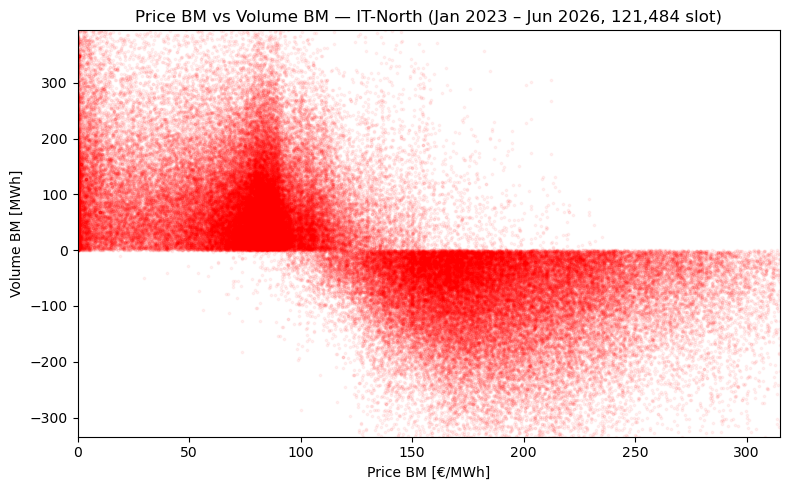

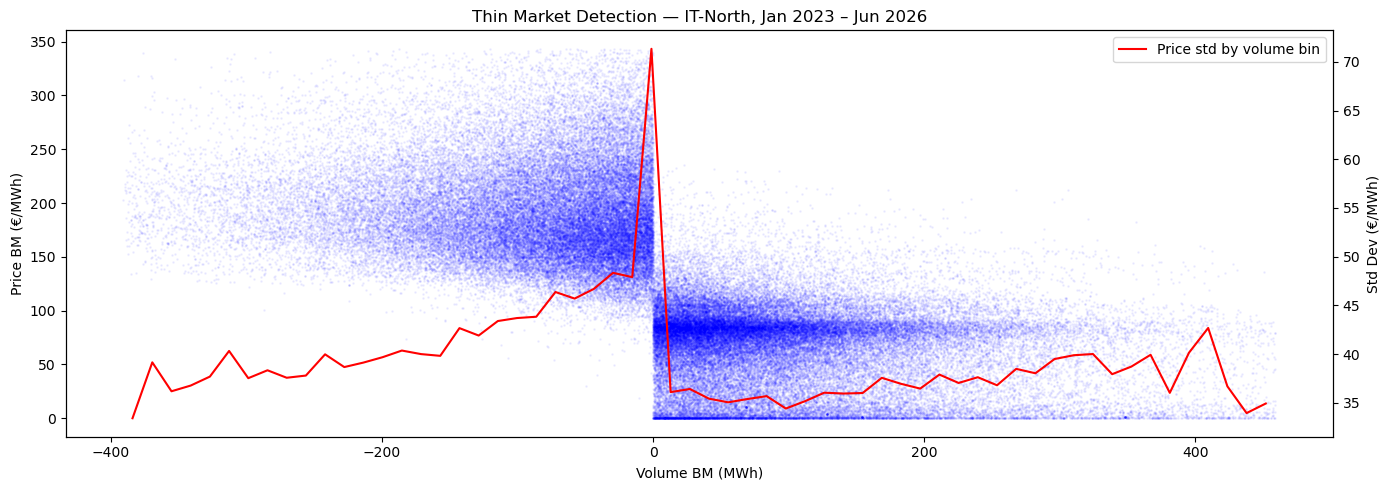

In [ ]:
import matplotlib.pyplot as plt

V = m["Sbil aggregato zonale [MWh]"]
P = m["Prezzo di sbilanciamento"]

lo_v, hi_v = V.quantile(0.005), V.quantile(0.995)
lo_p, hi_p = P.quantile(0.01),  P.quantile(0.99)
sub = m[(V.between(lo_v, hi_v)) & (P.between(lo_p, hi_p))].copy()

# bin a numerosità costante: gli equal-width lasciano bin da 50 punti alle code
sub["vbin"] = pd.qcut(sub["Sbil aggregato zonale [MWh]"], q=40, duplicates="drop")
g = sub.groupby("vbin", observed=True)["Prezzo di sbilanciamento"]
stat = g.std()
centers = [iv.mid for iv in stat.index]



# ---- 1) Scatter rosso: Price BM (x) vs Volume BM (y) ----
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(P, V, alpha=0.05, s=3, color="red")      # alpha più basso: 3.5 anni, non 8 mesi
ax.set_xlim(P.quantile(0.01), P.quantile(0.99))
ax.set_ylim(V.quantile(0.01), V.quantile(0.99))
ax.set_xlabel("Price BM [€/MWh]")
ax.set_ylabel("Volume BM [MWh]")
ax.set_title(f"Price BM vs Volume BM — IT-North ({periodo})")
plt.tight_layout()
plt.show()

V = m["Sbil aggregato zonale [MWh]"]
P = m["Prezzo di sbilanciamento"]

sub = m[V.between(V.quantile(0.005), V.quantile(0.995)) &
        P.between(P.quantile(0.005), P.quantile(0.995))].copy()

fig, ax4 = plt.subplots(figsize=(14, 5))
ax4.scatter(sub["Sbil aggregato zonale [MWh]"], sub["Prezzo di sbilanciamento"],
            color="blue", alpha=0.05, s=1)

vol_bin = pd.cut(sub["Sbil aggregato zonale [MWh]"], bins=60)   # ~13 MWh/bin sul range ritagliato
vol_std = sub.groupby(vol_bin, observed=True)["Prezzo di sbilanciamento"].std()
centers = [iv.mid for iv in vol_std.index]

ax5 = ax4.twinx()
ax5.plot(centers, vol_std.values, color="red", linewidth=1.5, label="Price std by volume bin")
# for x in (-15, 12):
#     ax4.axvline(x, color="black", linestyle="--", linewidth=0.8)

ax4.set_xlabel("Volume BM (MWh)"); ax4.set_ylabel("Price BM (€/MWh)")
ax5.set_ylabel("Std Dev (€/MWh)"); ax5.legend(loc="upper right")
ax4.set_title("Thin Market Detection — IT-North, Jan 2023 – Jun 2026")
plt.tight_layout(); plt.show()


